# 🧠 Deep Learning avec PyTorch
### Un cours intensif de 3 heures

**Thèmes abordés :**
1. Introduction aux réseaux de neurones
2. Optimiseurs, fonctions de coût & entraînement
3. Réseaux de neurones convolutifs (CNN)
4. Transformers & Self-Attention

> Tous les exemples utilisent **PyTorch** 🔥


---
# Partie 1 - Intorduction aux réseaux de neurones


## 1.1 Qu'est-ce qu'un neurone ?

Avant de parler de *réseaux*, comprenons le bloc fondamental : un **neurone**.

Imaginons que vous essayez de prédire si une photo représente un chien 🐶 ou non, à partir de certaines caractéristiques $x_1, x_2, \ldots, x_n$ (valeurs de pixels, histogrammes de couleurs, etc.).

Un neurone effectue **deux opérations** :

**Étape 1 — Somme pondérée + biais :**
$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \sum_{k=1}^n w_k x_k + b$$

Chaque poids $w_k$ représente l'importance de la caractéristique $k$. Le biais $b$ décale le résultat.

**Étape 2 — Activation non-linéaire :**
$$\text{output} = f(z)$$

La fonction d'activation $f$ décide si le neurone « s'active ». Sans elle, empiler des neurones ne produirait qu'une transformation linéaire — quel que soit le nombre de couches !

Construisons-en un de zéro 👇


Weighted sum z = 3.800
After ReLU activation: 3.800


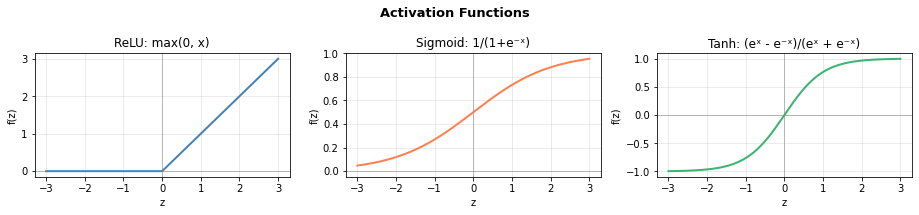

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A single sample: [size, fluffiness, ear_shape, tail_wagging]
X = np.array([0.8, 0.9, 0.6, 1.0])

# --- Step 1: a linear combination (like a linear regression) ---
def linreg(X):
    w = np.array([1.5, 2.0, -0.5, 3.1])
    b = -2.0
    return np.dot(w, X) + b

z = linreg(X)
print(f"Weighted sum z = {z:.3f}")

# --- Step 2: apply an activation function ---
def relu(x):
    return max(0, x)

output = relu(z)
print(f"After ReLU activation: {output:.3f}")

# ── Visualize what ReLU does ─────────────────────────────────
x_vals = np.linspace(-3, 3, 200)
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].plot(x_vals, np.maximum(0, x_vals), color='steelblue', lw=2)
axes[0].set_title("ReLU: max(0, x)"); axes[0].axhline(0, color='gray', lw=0.5); axes[0].axvline(0, color='gray', lw=0.5)

axes[1].plot(x_vals, 1/(1+np.exp(-x_vals)), color='coral', lw=2)
axes[1].set_title("Sigmoid: 1/(1+e⁻ˣ)"); axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)

axes[2].plot(x_vals, np.tanh(x_vals), color='mediumseagreen', lw=2)
axes[2].set_title("Tanh: (eˣ - e⁻ˣ)/(eˣ + e⁻ˣ)"); axes[2].axhline(0, color='gray', lw=0.5); axes[2].axvline(0, color='gray', lw=0.5)

for ax in axes:
    ax.set_xlabel("z"); ax.set_ylabel("f(z)"); ax.grid(alpha=0.3)
plt.suptitle("Activation Functions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1.2 Des neurones → aux couches → aux réseaux

Imaginez maintenant passer le **même signal d'entrée** par trois neurones différents en parallèle :

```python
out_1 = relu( 1.5·x₁ + 2.0·x₂ - 0.5·x₃ + 3.1·x₄  - 2.0 )   # neurone 1
out_2 = relu(-0.1·x₁ + 1.2·x₂ + 4.9·x₃ - 3.1·x₄  - 5.0 )   # neurone 2  
out_3 = relu( 0.4·x₁ + 2.6·x₂ - 2.5·x₃ + 3.8·x₄  - 8.0 )   # neurone 3
```

Ces trois neurones forment ensemble une **couche Dense** (aussi appelée couche entièrement connectée).

On passe ensuite `[out_1, out_2, out_3]` dans **une autre** couche... puis une autre...

C'est un **Réseau de Neurones** — et le *Deep Learning* désigne simplement un réseau avec **de nombreuses couches**.

$$\hat{y} = f_{\theta}(x)$$

où $\theta$ représente l'ensemble des poids de toutes les couches, appris lors de l'entraînement.

![Réseau de Neurones](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/neuralnet_4.png)

❓ **Question :** Si la première couche a 4 entrées et 3 neurones, et la deuxième couche a 1 neurone — combien de poids sont entraînés au total ?


## 1.3 PyTorch : votre framework de Deep Learning

**PyTorch** est un framework open-source de deep learning développé par Meta, reconnu pour sa flexibilité et son style pythonique.

C'est le framework dominant en recherche et de plus en plus en production.

💻 **Installation :**
```bash
pip install torch torchvision
```

📚 [Documentation officielle](https://pytorch.org/docs/stable/index.html)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


PyTorch version: 2.2.2
GPU available: False
Using device: cpu


## 1.4 Construire votre premier réseau de neurones

Avec PyTorch, il existe deux façons principales de définir un modèle.

### Option A — `nn.Sequential` (simple, empilement linéaire)

Idéal pour des architectures simples et linéaires.


In [ ]:
# A simple feedforward network for regression (input size 13 → 1 output)
model = nn.Sequential(
    nn.Linear(13, 50),   # Input layer: 13 features → 50 neurons
    nn.ReLU(),           # Activation
    nn.Linear(50, 10),   # Hidden layer
    nn.ReLU(),
    nn.Linear(10, 1)     # Output layer (linear = regression)
)

print(model)


### Option B — Sous-classer `nn.Module` (flexible, recommandé)

C'est la façon idiomatique en PyTorch et vous donne un contrôle total.


In [ ]:
class MyFirstNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))  # Hidden layer + activation
        x = self.fc2(x)             # Output layer (no activation = regression)
        return x

model = MyFirstNetwork(input_size=13, hidden_size=50, output_size=1)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")


## 1.5 La dernière couche : choisir la bonne sortie

La couche de sortie **doit correspondre à votre tâche** :

| Tâche | Dernière couche | Fonction de coût |
|---|---|---|
| Régression | `nn.Linear(n, 1)` (sans activation) | `nn.MSELoss()` |
| Classification binaire | `nn.Linear(n, 1)` + `nn.Sigmoid()` | `nn.BCELoss()` |
| Classification multi-classes (C classes) | `nn.Linear(n, C)` + `nn.Softmax(dim=1)` | `nn.CrossEntropyLoss()` |

> ⚠️ Remarque : `nn.CrossEntropyLoss()` en PyTorch inclut déjà le Softmax en interne — ne l'ajoutez pas deux fois !


In [ ]:
# Binary classification network
binary_model = nn.Sequential(
    nn.Linear(100, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()   # Output in [0, 1]
)

# Multi-class classification (5 classes)
multiclass_model = nn.Sequential(
    nn.Linear(100, 64),
    nn.ReLU(),
    nn.Linear(64, 5)
    # No Softmax here! CrossEntropyLoss handles it internally
)


---
# Partie 2 — Optimiseurs, fonctions de coût & entraînement


## 2.1 La boucle d'entraînement

Avec PyTorch, vous écrivez la **boucle d'entraînement explicitement**.

C'est plus verbeux mais vous donne un contrôle total sur chaque étape. Voici les trois phases :

**1. Définir l'architecture** → `nn.Module`  
**2. Définir la perte + l'optimiseur** → `nn.MSELoss()`, `optim.Adam()`  
**3. Entraîner** → boucle explicite sur les epochs et les mini-lots

$$\theta \leftarrow \theta - \alpha \cdot \nabla_{\theta} \mathcal{L}$$


## 2.2 Fonctions de coût

La fonction de coût mesure l'écart entre $y_{\text{pred}}$ et $y_{\text{true}}$.

| Tâche | Fonction de coût PyTorch |
|---|---|
| Régression | `nn.MSELoss()` |
| Classification binaire | `nn.BCELoss()` |
| Classification multi-classes (C classes) | `nn.CrossEntropyLoss()` |

> ⚠️ `nn.CrossEntropyLoss()` applique déjà le Softmax en interne — ne l'ajoutez pas deux fois dans votre modèle !


## 2.3 Optimiseurs

L'optimiseur met à jour $\theta$ pour minimiser la fonction de coût.

**Adam** est l'optimiseur de référence — taux d'apprentissage adaptatifs, fonctionne bien par défaut.

Hyperparamètre clé : **taux d'apprentissage** $\alpha$

| Trop élevé | Trop faible |
|---|---|
| La perte diverge 💥 | L'entraînement est très lent 🐢 |

Plage typique : `1e-4` à `1e-2`. Commencez avec `1e-3`.


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Load & prepare data ──────────────────────────────────────
housing = fetch_california_housing()
X, y = housing.data.astype(np.float32), housing.target.astype(np.float32)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # (N,) → (N,1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

print(f"Train: {X_train_t.shape}, Val: {X_val_t.shape}")


In [ ]:
# ── 1. Define model ─────────────────────────────────────────
model = nn.Sequential(
    nn.Linear(8, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
).to(device)

# ── 2. Loss & optimizer ─────────────────────────────────────
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ── 3. Training loop ─────────────────────────────────────────
N_EPOCHS   = 100
BATCH_SIZE = 32

train_losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    model.train()  # ← sets training mode (activates dropout, batch norm, etc.)
    
    # Mini-batch loop
    permutation = torch.randperm(X_train_t.size(0))
    batch_losses = []
    for i in range(0, X_train_t.size(0), BATCH_SIZE):
        idx = permutation[i:i+BATCH_SIZE]
        X_batch, y_batch = X_train_t[idx].to(device), y_train_t[idx].to(device)
        
        optimizer.zero_grad()      # 1. Reset gradients
        y_pred = model(X_batch)    # 2. Forward pass
        loss = criterion(y_pred, y_batch)  # 3. Compute loss
        loss.backward()            # 4. Backpropagation
        optimizer.step()           # 5. Update weights
        batch_losses.append(loss.item())
    
    train_losses.append(np.mean(batch_losses))
    
    # Validation (no gradient needed)
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t.to(device))
        val_loss = criterion(val_pred, y_val_t.to(device))
        val_losses.append(val_loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS}  |  Train MSE: {train_losses[-1]:.4f}  |  Val MSE: {val_losses[-1]:.4f}")


In [ ]:
# ── Plot training history ─────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training History")
plt.legend()
plt.tight_layout()
plt.show()


## 2.4 Utiliser DataLoader

Pour les jeux de données réels, le `DataLoader` de PyTorch gère automatiquement le **découpage en mini-lots**, le **mélange** et le **chargement parallèle** — pour un contrôle propre sur l'itération.


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Wrap tensors in a Dataset
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

print(f"Number of training batches per epoch: {len(train_loader)}")


## 2.5 Régularisation

Pour combattre contre le **surapprentissage** (*overfitting*), PyTorch propose :

- **Dropout** — désactive aléatoirement des neurones pendant l'entraînement → `nn.Dropout(p=0.3)`
- **L2 / Décroissance des poids** — pénalise les grands poids → `weight_decay=1e-4` dans l'optimiseur
- **Normalisation par lots** — normalise les activations → `nn.BatchNorm1d(n)`

> 🎯 **Stratégie :** faites d'abord **surapprendrer** votre modèle, puis régularisez.


In [ ]:
# Model with Dropout and BatchNorm
regularized_model = nn.Sequential(
    nn.Linear(8, 128),
    nn.BatchNorm1d(128),   # Normalize activations
    nn.ReLU(),
    nn.Dropout(p=0.3),     # Randomly zero 30% of neurons
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(64, 1)
)

# L2 regularization via weight_decay in Adam
optimizer_reg = optim.Adam(regularized_model.parameters(), lr=1e-3, weight_decay=1e-4)

print(regularized_model)


---
# Partie 3 — Réseaux de Neurones Convolutifs (CNN)


## 3.1 Pourquoi pas des réseaux Dense pour les images ?

Considérons une **image RGB de 128×128** en entrée :
- Taille aplatie : $128 \times 128 \times 3 = 49{,}152$ caractéristiques en entrée
- Une première couche Dense avec 256 neurones → **12,6 millions de paramètres** dans la première couche seulement !

C'est computationnellement prohibitif, et les couches Dense n'exploitent pas la **structure spatiale** des images.

![Problème de position](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/square_1_zoom.png)

> 💡 Un carré rouge en haut à gauche et un carré rouge en bas à droite devraient être reconnus de la même façon — les couches Dense traitent chaque position de pixel indépendamment.


## 3.2 L'opération de convolution

Une **convolution** fait glisser un petit **noyau** (*kernel* / filtre) sur l'image et calcule un produit scalaire à chaque position.

Voici le noyau que nous allons utiliser :
$$K = \begin{pmatrix} 1 & 0 & 1 \\ 0 & 1 & 0 \\ 1 & 0 & 1 \end{pmatrix}$$

**Étape 1** — Multiplication élément par élément du noyau avec le patch chevauché.  
**Étape 2** — Somme de tous les produits → une valeur de sortie.  
**Étape 3** — Faire glisser le noyau d'1 pixel (stride=1) et recommencer.

L'animation ci-dessous illustre cela en direct 👇


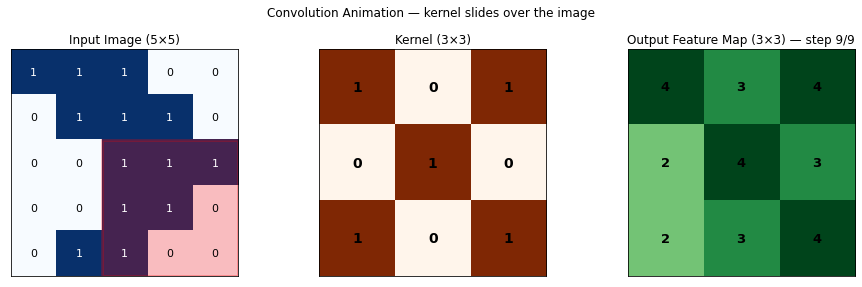

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ── Input image and kernel ────────────────────────────────────
image = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0],
], dtype=float)

kernel = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1],
], dtype=float)

H, W = image.shape
kH, kW = kernel.shape
outH, outW = H - kH + 1, W - kW + 1

# Pre-compute all output values
output = np.zeros((outH, outW))
for r in range(outH):
    for c in range(outW):
        output[r, c] = np.sum(image[r:r+kH, c:c+kW] * kernel)

# ── Build animation ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Convolution Animation — kernel slides over the image", fontsize=12)

cmap_img = 'Blues'
cmap_out = 'Greens'

ax_img, ax_ker, ax_out = axes

# Static kernel plot
ax_ker.imshow(kernel, cmap='Oranges', vmin=0, vmax=1)
ax_ker.set_title("Kernel (3×3)")
for r in range(kH):
    for c in range(kW):
        ax_ker.text(c, r, int(kernel[r, c]), ha='center', va='center',
                    fontsize=14, fontweight='bold')
ax_ker.set_xticks([]); ax_ker.set_yticks([])

# Image plot
im_img = ax_img.imshow(image, cmap=cmap_img, vmin=0, vmax=1)
ax_img.set_title("Input Image (5×5)")
for r in range(H):
    for c in range(W):
        ax_img.text(c, r, int(image[r, c]), ha='center', va='center',
                    fontsize=11, color='white' if image[r,c]>0.5 else 'black')
ax_img.set_xticks([]); ax_img.set_yticks([])

# Output plot (starts blank)
out_display = np.full((outH, outW), np.nan)
im_out = ax_out.imshow(out_display, cmap=cmap_out, vmin=0, vmax=4)
ax_out.set_title("Output Feature Map (3×3)")
texts_out = [[ax_out.text(c, r, '', ha='center', va='center', fontsize=13, fontweight='bold')
              for c in range(outW)] for r in range(outH)]
ax_out.set_xticks([]); ax_out.set_yticks([])

# Highlight rectangle on the input image
rect = patches.Rectangle((-0.5, -0.5), kW, kH,
                           linewidth=3, edgecolor='red', facecolor='red', alpha=0.25)
ax_img.add_patch(rect)

def update(frame):
    r, c = divmod(frame, outW)
    # Move red rectangle
    rect.set_xy((c - 0.5, r - 0.5))
    # Fill output cell
    out_display[r, c] = output[r, c]
    im_out.set_data(out_display)
    texts_out[r][c].set_text(int(output[r, c]))
    ax_out.set_title(f"Output Feature Map (3×3) — step {frame+1}/{outH*outW}")
    return [rect, im_out] + [texts_out[rr][cc] for rr in range(outH) for cc in range(outW)]

n_frames = outH * outW
anim = FuncAnimation(fig, update, frames=n_frames, interval=700, blit=False, repeat=True)
plt.tight_layout()
HTML(anim.to_jshtml())


## 3.3 Pooling

Le **Max Pooling** réduit les dimensions spatiales en prenant la valeur maximale dans chaque fenêtre.

Avantages :
- Réduit le coût de calcul et la mémoire utilisée
- Apporte une certaine robustesse aux translations
- `nn.MaxPool2d(kernel_size=2, stride=2)` divise H et W par 2


## 3.4 Un CNN en PyTorch

L'architecture typique d'un CNN :

```
[Conv → ReLU → Pool] × N  →  Flatten  →  Couches Dense  →  Sortie
```

![Architecture CNN](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/conv_network.png)


In [ ]:
class SimpleCNN(nn.Module):
    """
    A small CNN for image classification.
    Input: (batch, channels, H, W)
    """
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        
        # --- Convolutional blocks ---
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),  # (B, 32, H, W)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                     # (B, 32, H/2, W/2)
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),           # (B, 64, H/2, W/2)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                     # (B, 64, H/4, W/4)
        )
        
        # --- Classifier head ---
        # After 2 MaxPool(2,2) on a 28x28 input: 28/4 = 7 → 64*7*7 = 3136
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate and inspect
cnn = SimpleCNN(in_channels=1, num_classes=10)
print(cnn)

# Check output shape with a dummy input (batch=4, grayscale 28x28)
dummy = torch.zeros(4, 1, 28, 28)
print(f"\nInput shape:  {dummy.shape}")
print(f"Output shape: {cnn(dummy).shape}")

total_params = sum(p.numel() for p in cnn.parameters())
print(f"Total parameters: {total_params:,}")


## 3.5 Entraîner le CNN sur MNIST


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ── Data pipeline ─────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),                  # PIL image → [0,1] tensor
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean & std
])

train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
val_data   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader_mnist = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader_mnist   = DataLoader(val_data,   batch_size=64, shuffle=False)

# Visualize a few samples
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label))
    ax.axis('off')
plt.suptitle("MNIST Samples")
plt.tight_layout()
plt.show()


In [ ]:
# ── Train the CNN ────────────────────────────────────────────
cnn_model = SimpleCNN(in_channels=1, num_classes=10).to(device)
criterion_cls = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=1e-3)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct += (logits.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

N_EPOCHS_CNN = 5  # Keep short for demo — increase for better accuracy
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(N_EPOCHS_CNN):
    tr_loss, tr_acc = train_epoch(cnn_model, train_loader_mnist, optimizer_cnn, criterion_cls)
    vl_loss, vl_acc = eval_epoch(cnn_model, val_loader_mnist, criterion_cls)
    
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    
    print(f"Epoch {epoch+1}/{N_EPOCHS_CNN}  |  "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f}  |  "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f}")


In [ ]:
# ── Plot results ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Validation")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Validation")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()


## 3.6 Apprentissage par transfert & réseaux pré-entraînés

Entraîner des CNN depuis zéro nécessite d'énormes jeux de données. À la place, on utilise des **réseaux pré-entraînés** sur ImageNet (1,2M images, 1000 classes) :

| Architecture | Année | Paramètres | Top-5 Accuracy |
|---|---|---|---|
| AlexNet | 2012 | 60M | 84,7 % |
| VGG-16 | 2014 | 138M | 92,7 % |
| ResNet-50 | 2015 | 25M | 93,3 % |
| EfficientNet-B0 | 2019 | 5,3M | 94,9 % |

**Stratégie d'apprentissage par transfert :**
1. Charger un modèle pré-entraîné (poids gelés)
2. Remplacer la dernière couche de classification
3. Entraîner uniquement la nouvelle tête, ou dégeler progressivement


In [ ]:
import torchvision.models as models

# Load ResNet-18 with pre-trained ImageNet weights
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in backbone.parameters():
    param.requires_grad = False

# Replace the final fully-connected layer for our task (e.g., 10 classes)
num_features = backbone.fc.in_features
backbone.fc = nn.Linear(num_features, 10)  # Only this layer will be trained

print(f"Output layer: {backbone.fc}")
print(f"Trainable parameters: {sum(p.numel() for p in backbone.parameters() if p.requires_grad):,}")
print(f"Frozen parameters:    {sum(p.numel() for p in backbone.parameters() if not p.requires_grad):,}")


## 3.7 Augmentation de données

Quand votre jeu de données est petit, **augmentez-le** à la volée pour améliorer la généralisation.

`torchvision.transforms` applique des transformations aléatoires **uniquement pendant l'entraînement** — le modèle ne voit jamais exactement la même image deux fois.

La cellule ci-dessous génère une image et montre l'effet de chaque augmentation 👇


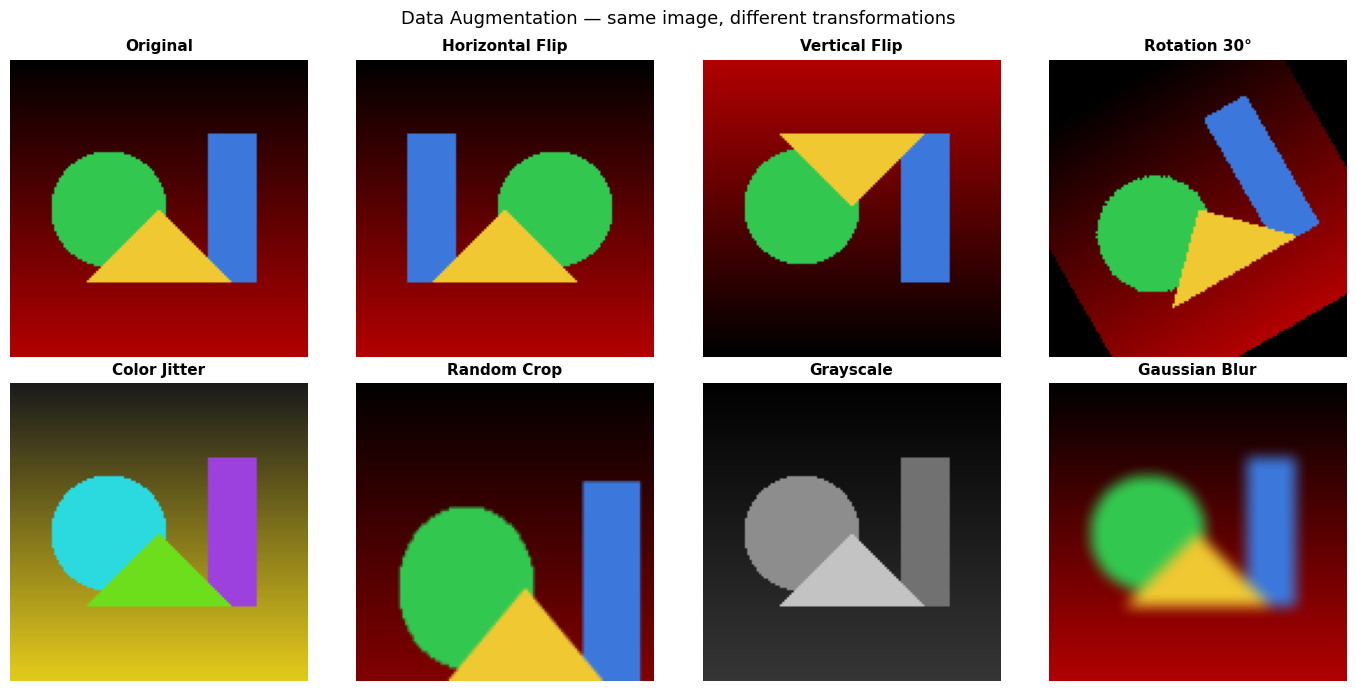

Training pipeline (with augmentation):
Validation pipeline (no augmentation — normalization only):
Both pipelines ready!


In [2]:
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
import torch

# ── Load a simple, license-free test image (cat from torchvision) ───
# We'll synthesise a colourful geometric image so no download is needed
def make_demo_image(size=128):
    """Create a synthetic image good enough to demonstrate augmentations."""
    img = np.zeros((size, size, 3), dtype=np.uint8)
    # Background gradient
    for i in range(size):
        img[i, :, 0] = int(180 * i / size)  # red gradient top→bottom
    # Green circle
    cx, cy, r = size//3, size//2, size//5
    for y in range(size):
        for x in range(size):
            if (x-cx)**2 + (y-cy)**2 < r**2:
                img[y, x] = [50, 200, 80]
    # Blue rectangle
    img[size//4:3*size//4, 2*size//3:5*size//6] = [60, 120, 220]
    # Yellow triangle (approximate)
    for y in range(size//2, 3*size//4):
        width = (y - size//2) * 2
        x0 = size//2 - width//2
        x1 = size//2 + width//2
        img[y, max(0,x0):min(size,x1)] = [240, 200, 50]
    return Image.fromarray(img)

original = make_demo_image()

# ── Define augmentation transforms ──────────────────────────────────
augmentations = {
    "Original":            T.Compose([]),
    "Horizontal Flip":     T.RandomHorizontalFlip(p=1.0),
    "Vertical Flip":       T.RandomVerticalFlip(p=1.0),
    "Rotation 30°":        T.RandomRotation(degrees=(30, 30)),
    "Color Jitter":        T.ColorJitter(brightness=0.5, contrast=0.5,
                                          saturation=0.5, hue=0.2),
    "Random Crop":         T.RandomResizedCrop(128, scale=(0.5, 0.75)),
    "Grayscale":           T.Grayscale(num_output_channels=3),
    "Gaussian Blur":       T.GaussianBlur(kernel_size=11, sigma=3.0),
}

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for ax, (name, transform) in zip(axes, augmentations.items()):
    aug_img = transform(original)
    ax.imshow(aug_img)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.axis('off')
    if name != "Original":
        ax.spines['bottom'].set_visible(True)
        for spine in ax.spines.values():
            spine.set_edgecolor('tomato')
            spine.set_linewidth(2)
            spine.set_visible(True)

fig.suptitle("Data Augmentation — same image, different transformations", fontsize=13)
plt.tight_layout()
plt.show()

# ── Training vs Validation pipeline ──────────────────────────────────
print("Training pipeline (with augmentation):")
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.RandomResizedCrop(128, scale=(0.8, 1.0)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Validation pipeline (no augmentation — normalization only):")
val_transform = T.Compose([
    T.Resize(144),
    T.CenterCrop(128),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print("Both pipelines ready!")


---
# Partie 4 — Transformers & Self-Attention


## 4.1 Les limites des CNN pour les séquences

Les CNN et les RNN peinent avec les **dépendances à longue portée** dans les séquences.

Place aux **Transformers** (Vaswani et al., 2017 — *« Attention is All You Need »*) :
- Traitent tous les tokens **en parallèle** (pas de récurrence)
- Modélisent directement les relations entre **deux positions quelconques**
- Passent très bien à l'échelle avec les données et le calcul → GPT, BERT, T5, LLaMA...

![Transformer](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/Transformers/one_encoder_block.png)


## 4.2 Tokenisation & Embeddings

Avant toute opération d'attention, le texte est converti en vecteurs :

1. **Tokeniser** — découper le texte en tokens (mots, sous-mots, caractères)
2. **Projeter** — associer chaque identifiant de token à un vecteur dense via une table de correspondance apprise

```
"Hello world" → [5432, 1234] → [[0.2, -0.1, ...], [0.8, 0.3, ...]]
```

En PyTorch : `nn.Embedding(vocab_size, embed_dim)`


In [ ]:
# Simple embedding example
vocab_size = 10_000   # Number of unique tokens
embed_dim  = 512      # Embedding dimension (d_model in the paper)

embedding_layer = nn.Embedding(vocab_size, embed_dim)

# Simulate a batch of 2 sentences, each 5 tokens long
token_ids = torch.randint(0, vocab_size, (2, 5))  # shape: (batch, seq_len)
embeddings = embedding_layer(token_ids)

print(f"Token IDs shape:    {token_ids.shape}")
print(f"Embeddings shape:   {embeddings.shape}  ← (batch, seq_len, embed_dim)")


## 4.3 Encodage positionnel

L'attention est **insensible à la position** — elle ne connaît pas l'ordre des tokens.  
On y remédie en ajoutant des **encodages positionnels** aux embeddings.

L'article original utilise des fonctions sinusoïdales :

$$PE_{(pos, 2i)}   = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$


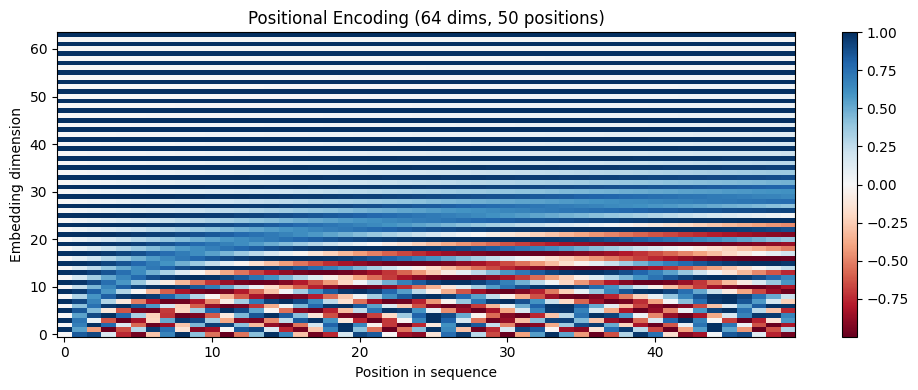

In [3]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (Vaswani et al. 2017)."""
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Compute the encoding matrix once
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)  # even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # odd indices
        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)   # not a parameter, but saved with model
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# Visualize the positional encoding
pe_layer = PositionalEncoding(d_model=64, max_len=50)
pe_values = pe_layer.pe[0].numpy()  # (50, 64)

plt.figure(figsize=(10, 4))
plt.imshow(pe_values.T, aspect='auto', cmap='RdBu', origin='lower')
plt.colorbar()
plt.xlabel("Position in sequence")
plt.ylabel("Embedding dimension")
plt.title("Positional Encoding (64 dims, 50 positions)")
plt.tight_layout()
plt.show()


## 4.4 Self-Attention : le mécanisme central

### Étape 0 — Intuition : de la recherche exacte à la recherche douce

Pensez à un dictionnaire Python :

```python
words = {"cat": "animal", "dog": "animal", "talk": "verb", "eat": "verb", "brown": "color"}
words["dog"]    # → "animal"  ✅ correspondance exacte
words["puppy"]  # → KeyError  ❌
```

Et si la requête n'est pas une clé exacte ? Avec les **embeddings**, clés et requêtes sont des vecteurs. On peut mesurer la *similarité* :

| Clé   | Valeur   | Similarité avec *« puppy »* | Similarité avec *« bark »* |
|-------|----------|:---------------------------:|:--------------------------:|
| dog   | animal   | **0,8**                     | **0,7**                    |
| cat   | animal   | 0,2                         | 0,1                        |
| talk  | verb     | 0,1                         | **0,6**                    |
| eat   | verb     | 0,1                         | 0,1                        |
| brown | color    | **0,6**                     | 0,1                        |

- Requête **« puppy »** → obtient surtout *animal* + un peu de *color*
- Requête **« bark »** → obtient surtout *animal* + un peu de *verb*

C'est la **recherche douce** : au lieu de récupérer une valeur exacte, on obtient un **mélange pondéré de toutes les valeurs**.  
C'est l'essence de l'attention. 💡

---

### Étape 1 — Projeter en Q, K, V

Chaque embedding de token est projeté (via des matrices de poids apprises) en trois vecteurs :

- 🟣 **Query** $Q$ : *« Que cherche-je ? »*
- 🟠 **Key** $K$ : *« Qui suis-je / que représente-je ? »*
- 🔵 **Value** $V$ : *« Quelle information vais-je transmettre ? »*

$$Q = X W_Q \qquad K = X W_K \qquad V = X W_V$$

### Étape 2 — Calculer les scores de similarité

$$\text{score}(q_i, k_j) = \frac{q_i \cdot k_j}{\sqrt{d_k}}$$

La mise à l'échelle par $\sqrt{d_k}$ empêche les scores d'exploser en grande dimension.

### Étape 3 — Softmax → poids d'attention

$$\alpha_{ij} = \text{softmax}\left(\frac{q_i \cdot k_j}{\sqrt{d_k}}\right)$$

Les poids somment à 1 — ils indiquent au token $i$ *à quel point il doit prêter attention* au token $j$.

### Étape 4 — Somme pondérée des valeurs

$$\text{output}_i = \sum_j \alpha_{ij} \cdot v_j$$

Forme matricielle complète : $\text{Attention}(Q, K, V) = \text{softmax}\!\left(\dfrac{QK^T}{\sqrt{d_k}}\right)V$

La cellule ci-dessous rend les quatre étapes interactives 👇


/Users/lucasn1/.pyenv/versions/3.11.0/envs/taxifare-env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/lucasn1/.pyenv/versions/3.11.0/envs/taxifare-env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/lucasn1/.pyenv/versions/3.11.0/envs/taxifare-env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


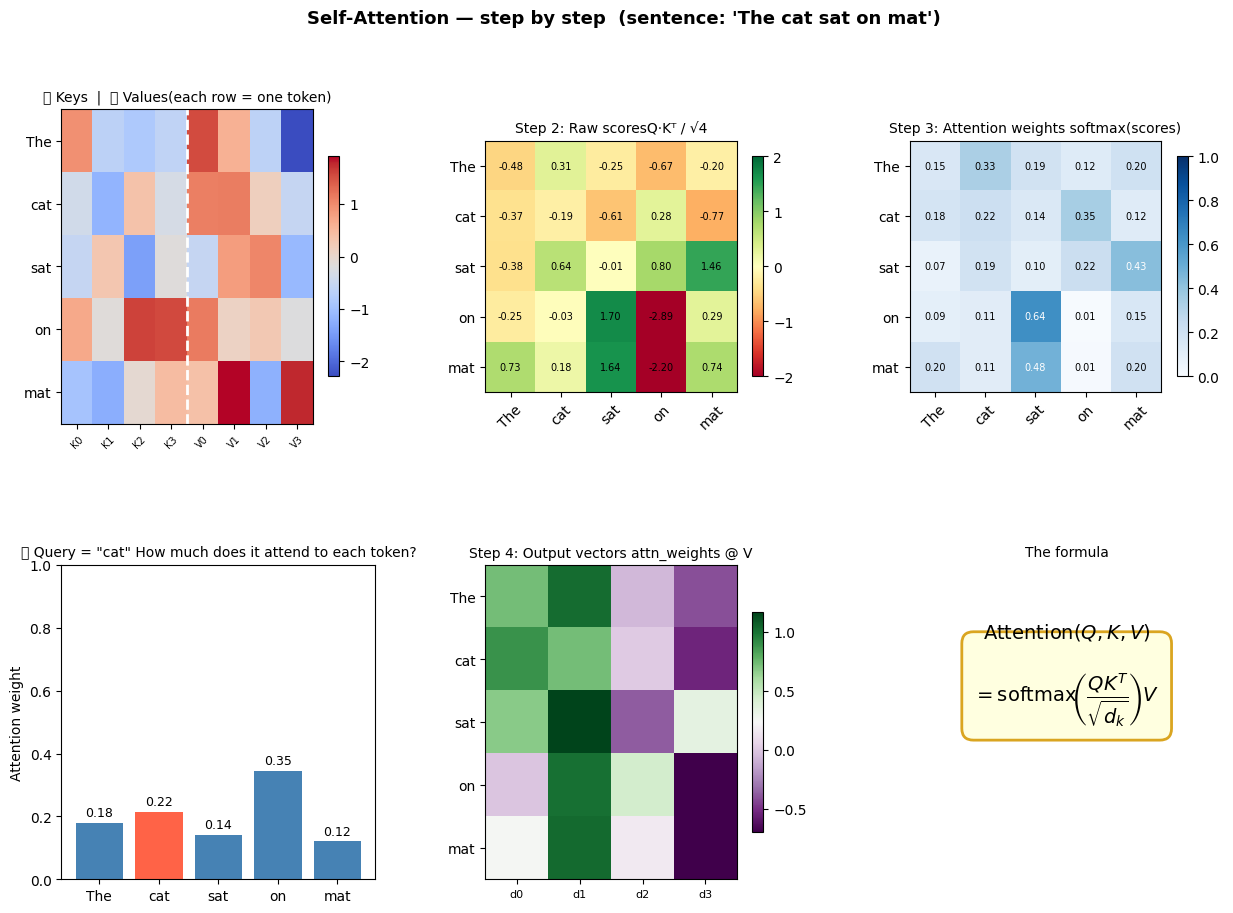


Attention weight matrix (rows = query token, cols = key token):
             The     cat     sat      on     mat
The        0.152   0.333   0.191   0.124   0.200
cat        0.179   0.215   0.141   0.345   0.120
sat        0.068   0.188   0.098   0.220   0.426
on         0.090   0.113   0.635   0.006   0.155
mat        0.196   0.112   0.484   0.010   0.197

Each row sums to 1.0  ✓
Row sums: [1. 1. 1. 1. 1.]


In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Toy sentence: 5 tokens ────────────────────────────────────────────
tokens = ["The", "cat", "sat", "on", "mat"]
n, d_model, d_k = len(tokens), 8, 4

torch.manual_seed(7)
# Simulate token embeddings already projected into Q, K, V
Q = torch.randn(n, d_k)
K = torch.randn(n, d_k)
V = torch.randn(n, d_k)

# ── Step 2: raw scores ────────────────────────────────────────────────
raw_scores = (Q @ K.T) / (d_k ** 0.5)          # (n, n)

# ── Step 3: attention weights ─────────────────────────────────────────
attn_weights = torch.softmax(raw_scores, dim=-1)  # (n, n)

# ── Step 4: output ────────────────────────────────────────────────────
output = attn_weights @ V                          # (n, d_k)

# ── Visualise everything ──────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- (A) KV table as heatmap ---
ax_kv = fig.add_subplot(gs[0, 0])
kv_data = np.column_stack([K.numpy(), V.numpy()])
im = ax_kv.imshow(kv_data, cmap='coolwarm', aspect='auto')
ax_kv.set_xticks(range(d_k*2))
ax_kv.set_xticklabels([f'K{i}' for i in range(d_k)] + [f'V{i}' for i in range(d_k)], fontsize=7, rotation=45)
ax_kv.set_yticks(range(n)); ax_kv.set_yticklabels(tokens)
ax_kv.set_title("🟠 Keys  |  🔵 Values(each row = one token)", fontsize=10)
ax_kv.axvline(d_k - 0.5, color='white', lw=2, linestyle='--')
plt.colorbar(im, ax=ax_kv, shrink=0.7)

# --- (B) Raw dot-product scores ---
ax_raw = fig.add_subplot(gs[0, 1])
im2 = ax_raw.imshow(raw_scores.numpy(), cmap='RdYlGn', vmin=-2, vmax=2)
ax_raw.set_xticks(range(n)); ax_raw.set_xticklabels(tokens, rotation=45)
ax_raw.set_yticks(range(n)); ax_raw.set_yticklabels(tokens)
ax_raw.set_title(f"Step 2: Raw scoresQ·Kᵀ / √{d_k}", fontsize=10)
for r in range(n):
    for c in range(n):
        ax_raw.text(c, r, f"{raw_scores[r,c]:.2f}", ha='center', va='center', fontsize=7)
plt.colorbar(im2, ax=ax_raw, shrink=0.7)

# --- (C) Attention weights (after softmax) ---
ax_attn = fig.add_subplot(gs[0, 2])
im3 = ax_attn.imshow(attn_weights.numpy(), cmap='Blues', vmin=0, vmax=1)
ax_attn.set_xticks(range(n)); ax_attn.set_xticklabels(tokens, rotation=45)
ax_attn.set_yticks(range(n)); ax_attn.set_yticklabels(tokens)
ax_attn.set_title("Step 3: Attention weights softmax(scores)", fontsize=10)
for r in range(n):
    for c in range(n):
        val = attn_weights[r, c].item()
        color = 'white' if val > 0.4 else 'black'
        ax_attn.text(c, r, f"{val:.2f}", ha='center', va='center', fontsize=7, color=color)
plt.colorbar(im3, ax=ax_attn, shrink=0.7)

# --- (D) Zoom: attention FROM "cat" ---
ax_bar = fig.add_subplot(gs[1, 0])
cat_idx = tokens.index("cat")
bars = ax_bar.bar(tokens, attn_weights[cat_idx].numpy(),
                  color=['tomato' if t == "cat" else 'steelblue' for t in tokens])
ax_bar.set_ylabel("Attention weight"); ax_bar.set_ylim(0, 1)
ax_bar.set_title(f'🟣 Query = "{tokens[cat_idx]}" How much does it attend to each token?', fontsize=10)
for bar, val in zip(bars, attn_weights[cat_idx].numpy()):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.2f}", ha='center', fontsize=9)

# --- (E) Output vectors ---
ax_out = fig.add_subplot(gs[1, 1])
im4 = ax_out.imshow(output.numpy(), cmap='PRGn', aspect='auto')
ax_out.set_yticks(range(n)); ax_out.set_yticklabels(tokens)
ax_out.set_xticks(range(d_k)); ax_out.set_xticklabels([f'd{i}' for i in range(d_k)], fontsize=8)
ax_out.set_title("Step 4: Output vectors attn_weights @ V", fontsize=10)
plt.colorbar(im4, ax=ax_out, shrink=0.7)

# --- (F) The formula ---
ax_eq = fig.add_subplot(gs[1, 2])
ax_eq.axis('off')
ax_eq.text(0.5, 0.65,
    r"$\mathrm{Attention}(Q, K, V)$" + "\n\n" +
    r"$= \mathrm{softmax}\!\left(\dfrac{QK^T}{\sqrt{d_k}}\right)V$",
    ha='center', va='center', fontsize=14,
    bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow', edgecolor='goldenrod', lw=2))
ax_eq.set_title("The formula", fontsize=10)

fig.suptitle("Self-Attention — step by step  (sentence: 'The cat sat on mat')",
             fontsize=13, fontweight='bold')
plt.show()

# ── Print the numeric attention table ────────────────────────────────
print("\nAttention weight matrix (rows = query token, cols = key token):")
print(f"{'':8s}" + "".join(f"{t:>8s}" for t in tokens))
for i, row in enumerate(attn_weights):
    vals = "".join(f"{v.item():>8.3f}" for v in row)
    print(f"{tokens[i]:8s}{vals}")
print("\nEach row sums to 1.0  ✓")
print(f"Row sums: {attn_weights.sum(dim=1).numpy().round(4)}")


In [8]:
pip install torch -y

zsh compinit: insecure directories, run compaudit for list.
Ignore insecure directories and continue [y] or abort compinit [n]? ^C
Note: you may need to restart the kernel to use updated packages.


## 4.5 Attention multi-têtes

Au lieu d'une seule tête d'attention, on en utilise **plusieurs en parallèle**.

Chaque tête peut se concentrer sur différents aspects des relations :
- Une tête pourrait capturer les dépendances syntaxiques
- Une autre la similarité sémantique

Les sorties sont **concaténées** puis projetées vers $d_{model}$.

![Multi-Head Attention](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/Transformers/inside-self-attention.png)


In [ ]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Self-Attention (Vaswani et al. 2017).
    
    Each head operates on a d_k = d_model // num_heads dimensional subspace.
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        
        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        
        # Output projection
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    
    def split_heads(self, x):
        """(batch, seq, d_model) → (batch, heads, seq, d_k)"""
        B, S, _ = x.shape
        x = x.view(B, S, self.num_heads, self.d_k)
        return x.transpose(1, 2)
    
    def forward(self, x, mask=None):
        B, S, _ = x.shape
        
        # Project and split into heads
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))
        
        # Scaled dot-product attention per head
        attn_out, _ = scaled_dot_product_attention(Q, K, V, mask)
        
        # Concatenate heads and project back
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, S, self.d_model)
        return self.W_o(attn_out)

# ── Test ──────────────────────────────────────────────────────
mha = MultiHeadAttention(d_model=512, num_heads=8)
x   = torch.randn(2, 10, 512)  # batch=2, seq_len=10, d_model=512
out = mha(x)
print(f"Input:  {x.shape}")
print(f"Output: {out.shape}  ← same shape!")
print(f"Parameters in MHA: {sum(p.numel() for p in mha.parameters()):,}")


## 4.6 Le bloc encodeur du Transformer

Un **bloc encodeur** = Attention multi-têtes + Réseau Feed-Forward + Connexions résiduelles + Normalisation de couche.

```
x → [LayerNorm → MHA → + résiduel] → [LayerNorm → FFN → + résiduel] → sortie
```

Le motif **Add & Norm** est crucial :
- **Connexions résiduelles** : permettent aux gradients de circuler directement dans les réseaux profonds
- **Normalisation de couche** : stabilise l'entraînement


In [ ]:
class TransformerEncoderBlock(nn.Module):
    """
    One Transformer encoder block:
      x → LayerNorm → MultiHeadAttention → + x (residual)
        → LayerNorm → FeedForward        → + x (residual)
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        
        self.attention = MultiHeadAttention(d_model, num_heads)
        
        # Feed-Forward Network: d_model → d_ff → d_model
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        # Sub-layer 1: Multi-Head Attention + residual
        attn_out = self.attention(self.norm1(x), mask)  # Pre-norm variant
        x = x + self.dropout(attn_out)
        
        # Sub-layer 2: Feed-Forward + residual
        ffn_out = self.ffn(self.norm2(x))
        x = x + self.dropout(ffn_out)
        
        return x

# Test with a sequence
block = TransformerEncoderBlock(d_model=512, num_heads=8, d_ff=2048)
x = torch.randn(2, 10, 512)
out = block(x)
print(f"Input:  {x.shape}")
print(f"Output: {out.shape}")
print(f"Parameters in one encoder block: {sum(p.numel() for p in block.parameters()):,}")


## 4.7 Encodeur Transformer complet

On empile $N$ blocs encodeurs + embedding + encodage positionnel.


In [ ]:
class TransformerEncoder(nn.Module):
    """
    Full Transformer encoder (stacked encoder blocks).
    """
    def __init__(self, vocab_size, d_model=512, num_heads=8,
                 d_ff=2048, num_layers=6, max_len=512, dropout=0.1):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(d_model)
    
    def forward(self, token_ids, mask=None):
        # token_ids: (batch, seq_len)
        x = self.embedding(token_ids) * (self.embedding.embedding_dim ** 0.5)
        x = self.pos_enc(x)
        
        for layer in self.layers:
            x = layer(x, mask)
        
        return self.norm(x)  # (batch, seq_len, d_model)

# Instantiate
encoder = TransformerEncoder(vocab_size=10_000, d_model=128, num_heads=4,
                              d_ff=512, num_layers=3)

# Forward pass
token_ids = torch.randint(0, 10_000, (2, 20))  # batch=2, seq_len=20
output = encoder(token_ids)
print(f"Token IDs: {token_ids.shape}")
print(f"Encoder output: {output.shape}  ← (batch, seq_len, d_model)")
print(f"Total parameters: {sum(p.numel() for p in encoder.parameters()):,}")


## 4.8 Classification de texte avec un Transformer

Mettons tout ensemble pour une tâche d'**analyse de sentiment**.


In [ ]:
class TransformerClassifier(nn.Module):
    """
    Transformer encoder + classification head.
    Uses [CLS] token representation for sequence classification.
    """
    def __init__(self, vocab_size, num_classes, d_model=128, num_heads=4,
                 d_ff=256, num_layers=2, max_len=256, dropout=0.1):
        super().__init__()
        
        self.encoder = TransformerEncoder(
            vocab_size, d_model, num_heads, d_ff, num_layers, max_len, dropout
        )
        
        # Classification head: use the first token's representation
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )
    
    def forward(self, token_ids, mask=None):
        encoded = self.encoder(token_ids, mask)   # (batch, seq, d_model)
        cls_repr = encoded[:, 0, :]               # Take the first token
        return self.classifier(cls_repr)          # (batch, num_classes)

# Instantiate
clf = TransformerClassifier(vocab_size=10_000, num_classes=2)  # Binary sentiment

# Test
token_ids = torch.randint(0, 10_000, (4, 64))   # batch=4, seq_len=64
logits = clf(token_ids)
print(f"Input:  {token_ids.shape}")
print(f"Logits: {logits.shape}  ← (batch, num_classes)")
print(f"\nTotal model parameters: {sum(p.numel() for p in clf.parameters()):,}")


## 4.9 Utiliser des Transformers pré-entraînés avec 🤗 HuggingFace

En pratique, on n'entraîne presque jamais un Transformer depuis zéro. On utilise des **modèles pré-entraînés** de [HuggingFace](https://huggingface.co/) :

- **BERT** — encodeur, excellent pour la classification & la reconnaissance d'entités
- **GPT-2 / GPT-4** — décodeur, excellent pour la génération de texte
- **T5 / BART** — encodeur-décodeur, excellent pour la traduction & le résumé

```bash
pip install transformers datasets
```


In [ ]:
# Example: Fine-tuning BERT for sentiment analysis
# (requires `pip install transformers`)

hf_example = '''
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load pre-trained BERT tokenizer and model
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Freeze all layers except the classifier head
for param in model.bert.parameters():
    param.requires_grad = False

# Only the final classifier is trained
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} parameters")

# Inference example
text = "This movie was absolutely fantastic!"
inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
with torch.no_grad():
    logits = model(**inputs).logits
probs = torch.softmax(logits, dim=-1)
label = "positive" if probs[0][1] > 0.5 else "negative"
print(f"Sentiment: {label} ({probs[0][1]:.2%} confidence)")
'''

print("HuggingFace fine-tuning code (uncomment to run with `pip install transformers`):")
print(hf_example)


---
## 🎯 Récapitulatif

### La boucle d'entraînement PyTorch en 5 étapes

```python
for epoch in range(N_EPOCHS):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()      # 1. Réinitialiser les gradients
        y_pred = model(X_batch)    # 2. Passe avant (forward)
        loss = criterion(y_pred, y_batch)  # 3. Calculer la perte
        loss.backward()            # 4. Rétropropagation
        optimizer.step()           # 5. Mettre à jour les poids
```

### Bonnes pratiques à retenir 🔑

1. **Toujours appeler `model.train()` avant l'entraînement et `model.eval()` avant l'évaluation**
2. **Toujours appeler `optimizer.zero_grad()` avant chaque passe arrière**
3. **Encapsuler l'évaluation dans `with torch.no_grad():`**
4. **Déplacer les tenseurs sur le bon device** avec `.to(device)`

### 📚 Pour aller plus loin

- [Tutoriels officiels PyTorch](https://pytorch.org/tutorials/)
- [The Deep Learning Bible (gratuit)](https://wikidocs.net/book/8027)
- [Le Transformer illustré par Jay Alammar](https://jalammar.github.io/illustrated-transformer/)
- [Cours NLP HuggingFace (gratuit)](https://huggingface.co/learn/nlp-course)
- [fast.ai — Deep Learning pratique (gratuit)](https://course.fast.ai/)
